# HVAC Demand analysis and prediction

## 2.1 Time series analysis


In [5]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# Statsmodels
import statsmodels.api as sm
import statsmodels.formula as smf
import statsmodels.tsa as smt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from pmdarima.model_selection import train_test_split

np.random.seed(42)


In [6]:
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df.set_index("Time", inplace=True)


In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
air_pressure,70080.0,734.587334,5.006131,716.500000,731.400000,734.200000,737.500000,757.500000
air_temperature,70080.0,17.874431,10.669905,-14.400000,10.000000,18.900000,25.600000,43.300000
relative_humidity,70080.0,60.645077,21.979472,4.000000,43.000000,61.000000,79.000000,100.000000
wind_speed,70080.0,4.830608,2.581267,0.000000,3.000000,5.000000,6.000000,26.000000
solar_irridiation,70080.0,257.293094,258.725788,0.000000,0.000000,299.500000,499.000000,699.000000
total_cloud_cover_percent,70080.0,0.323900,0.387351,0.000000,0.000000,0.000000,0.750000,1.000000
electricity_demand_values,70080.0,393.894392,239.177728,112.947618,227.708651,323.095501,476.911512,1592.893206
heat_demand_values,70080.0,263.551003,314.720551,0.000000,0.000000,137.430266,448.333458,1529.168786


In [25]:
print(df.dtypes)


air_pressure                 float64
air_temperature              float64
relative_humidity            float64
wind_speed                   float64
solar_irridiation              int64
total_cloud_cover_percent    float64
electricity_demand_values    float64
heat_demand_values           float64
dtype: object


In [27]:
demand_train = df.query("'2018-01-01 ' <= Time < '2018-01-16'")[
    "electricity_demand_values"
]


In [28]:
model = pm.auto_arima(
    demand_train,
    seasonal=True,
    trace=True,
    m=24,
    error_action="ignore",
    suppress_warnings=True,
)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=4.00 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=3916.253, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=0.84 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=inf, Time=1.89 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=3914.300, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=1.33 sec
 ARIMA(0,1,0)(0,0,1)[24] intercept   : AIC=inf, Time=0.69 sec
 ARIMA(0,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=3.44 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=3672.021, Time=0.13 sec
 ARIMA(1,1,0)(0,0,1)[24] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=3.04 sec
 ARIMA(2,1,0)(0,0,0)[24] intercept   : AIC=3593.877, Time=0.23 sec
 ARIMA(2,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=3.45 sec
 ARIMA(2,1,0)(0,0,1)[24] intercept   : AIC=3342.421, Time=1.46 sec
 ARIMA(2,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=5.41 sec
 A

In [29]:
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  360
Model:             SARIMAX(2, 1, 4)x(1, 0, [1], 24)   Log Likelihood               -1328.505
Date:                              Sat, 02 Dec 2023   AIC                           2677.010
Time:                                      12:33:02   BIC                           2715.843
Sample:                                  01-01-2018   HQIC                          2692.452
                                       - 01-15-2018                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0002      0.004     -0.049      0.961      -0.009       0.008
ar.L1          1.7019      0.061     27.710      0.000       1.582       1.822
ar.L2         -0.9671      0.062    -15.530      0.000      -1.089      -0.845
ma.L1         -1.5611      0.076    -20.609      0.000      -1.710      -1.413
ma.L2          0.8187      0.074     11.016      0.000       0.673       0.964
ma.L3          0.0230      0.014      1.669      0.095      -0.004       0.050
ma.L4          0.0311      0.006      5.487      0.000       0.020       0.042
ar.S.L24       0.9983      0.001   1101.665      0.000       0.997       1.000
ma.S.L24      -0.7834      0.047    -16.700      0.000      -0.875      -0.691
sigma2        75.0708      3.658     20.523      0.000      67.902      82.240
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                52.63
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.70   Skew:                             0.36
Prob(H) (two-sided):                  0.05   Kurtosis:                         4.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [32]:
test = df["electricity_demand_values"].loc[
    "2018-01-17 00:00:00":"2018-01-17 23:00:00"
]

forecast = model.predict(n_periods=len(test))
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)
# Print the results
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")


RMSE: 25.74508462932031
R2 Score: 0.9519382988426484


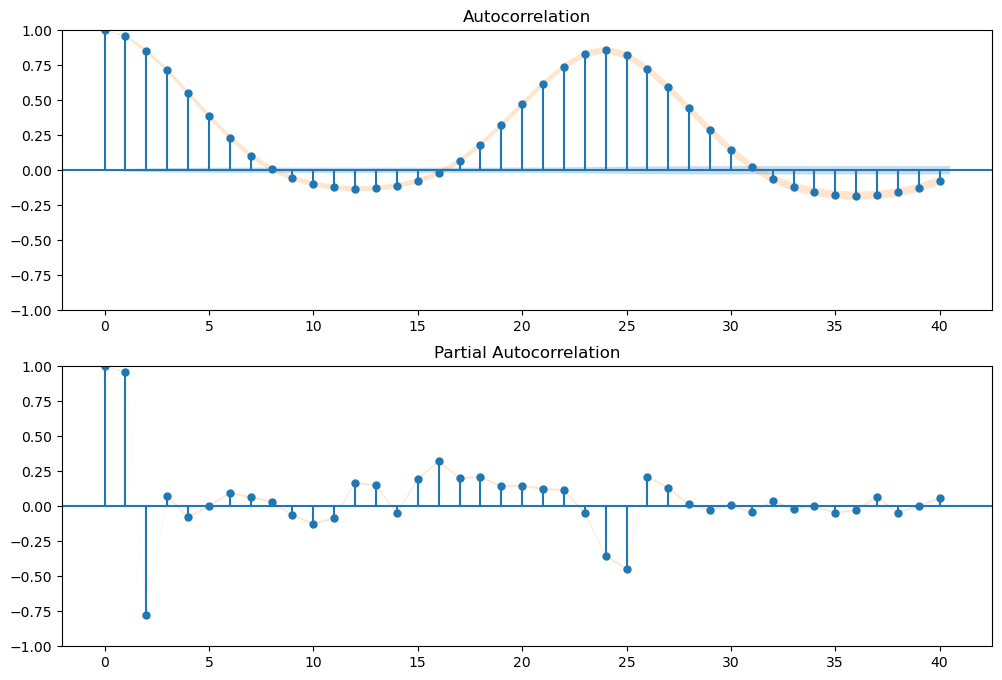

In [7]:
_, axes = plt.subplots(2, 1, figsize=(12, 8))

acf_result, confint = sm.tsa.acf(df["electricity_demand_values"], nlags=40, alpha=0.05)

sm.graphics.tsa.plot_acf(
    df["electricity_demand_values"], lags=40, ax=axes[0], alpha=0.05
)
axes[0].fill_between(range(len(acf_result)), confint[:, 0], confint[:, 1], alpha=0.2)

# PACF plot with confidence intervals
pacf_result, confint = sm.tsa.pacf(
    df["electricity_demand_values"], nlags=40, alpha=0.05
)
sm.graphics.tsa.plot_pacf(
    df["electricity_demand_values"], lags=40, ax=axes[1], alpha=0.05
)
axes[1].fill_between(range(len(pacf_result)), confint[:, 0], confint[:, 1], alpha=0.2)

plt.show()


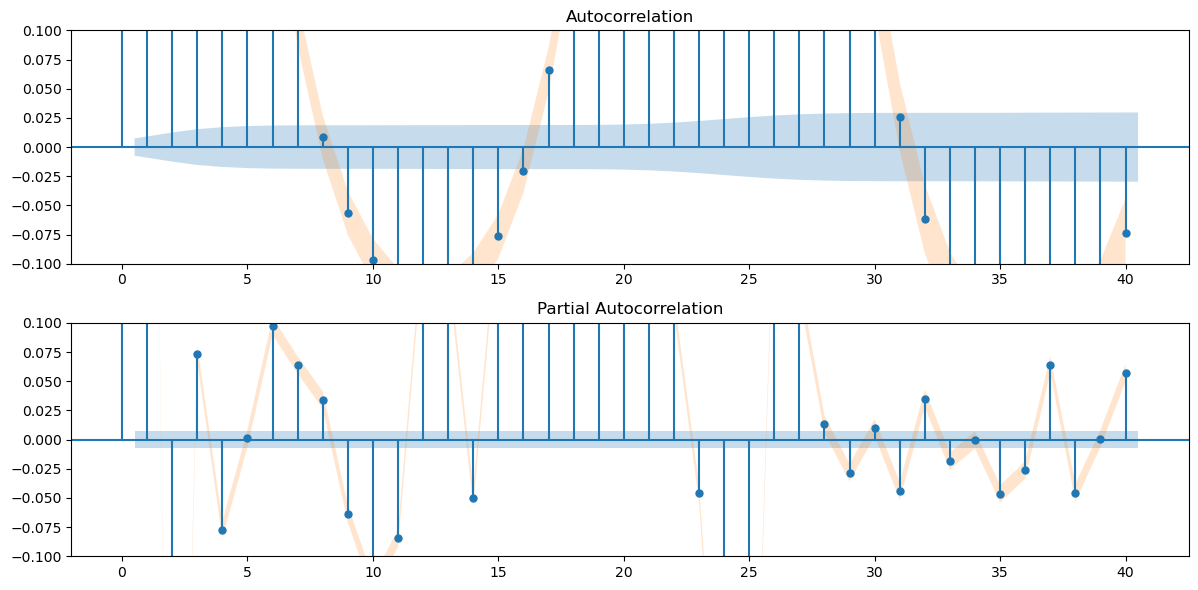

In [8]:
# ACF plot with confidence intervals
_, axes = plt.subplots(2, 1, figsize=(12, 6))

acf_result, confint = sm.tsa.acf(df["electricity_demand_values"], nlags=40, alpha=0.05)
sm.graphics.tsa.plot_acf(
    df["electricity_demand_values"], lags=40, ax=axes[0], alpha=0.05
)
axes[0].fill_between(range(len(acf_result)), confint[:, 0], confint[:, 1], alpha=0.2)
axes[0].set_ylim([-0.1, 0.1])
# PACF plot with confidence intervals
pacf_result, confint = sm.tsa.pacf(
    df["electricity_demand_values"], nlags=40, alpha=0.05
)
sm.graphics.tsa.plot_pacf(
    df["electricity_demand_values"], lags=40, ax=axes[1], alpha=0.05
)
axes[1].fill_between(range(len(pacf_result)), confint[:, 0], confint[:, 1], alpha=0.2)
axes[1].set_ylim([-0.1, 0.1])

plt.tight_layout()
plt.show()


In [9]:
stationary_result = sm.tsa.stattools.adfuller(df["electricity_demand_values"])


In [10]:
# Extract the ADF test results
adf_statistic, p_value, used_lag, nobs, critical_values, icbest = stationary_result

# Define a significance level (e.g., 0.05)
alpha = 0.05


In [11]:
if p_value <= alpha:
    print("The time series is stationary (reject the null hypothesis)")
else:
    print("The time series is not stationary (fail to reject the null hypothesis)")


The time series is stationary (reject the null hypothesis)


In [12]:
# Create a table for ADF test results
adf_table = pd.DataFrame(
    {
        "ADF Statistic": [adf_statistic],
        "P-Value": [p_value],
        "Used Lag": [used_lag],
        "Number of Observations": [nobs],
        "Critical Values (1%)": [critical_values["1%"]],
        "Critical Values (5%)": [critical_values["5%"]],
        "Critical Values (10%)": [critical_values["10%"]],
        "ICbest": [icbest],
    }
)


In [13]:
adf_table


,ADF Statistic,P-Value,Used Lag,Number of Observations,Critical Values (1%),Critical Values (5%),Critical Values (10%),ICbest
0,-18.076809,2.594138e-30,62,70017,-3.430443,-2.861581,-2.566792,658705.128654


## ARIMA and SARIMA

- First-order and second-order differencing


In [14]:
train_size = int(len(df) * 0.8)
train, test = df[0:train_size], df[train_size:]


In [15]:
model = ARIMA(train["electricity_demand_values"], order=(1, 0, 1))
model_fit = model.fit()
print(model_fit.summary())


                                   SARIMAX Results                                   
Dep. Variable:     electricity_demand_values   No. Observations:                56064
Model:                        ARIMA(1, 0, 1)   Log Likelihood             -298961.199
Date:                       Fri, 01 Dec 2023   AIC                         597930.398
Time:                               22:33:14   BIC                         597966.135
Sample:                                    0   HQIC                        597941.533
                                     - 56064                                         
Covariance Type:                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        390.4326      6.750     57.841      0.000     377.203     403.663
ar.L1          0.9373      0.001    816.407      0.000       0.935       0.

In [16]:
forecast = model_fit.predict(start=test.index[0], end=test.index[-1], order=(1, 0, 1))
forecast.index = test.index  # set the correct index


/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [17]:
mse = mean_squared_error(test["electricity_demand_values"], forecast)
rmse = np.sqrt(mse)
r2 = r2_score(test["electricity_demand_values"], forecast)
print(f"MSE: {mse}, RMSE: {rmse}, R²: {r2}")


MSE: 66263.31915904094, RMSE: 257.41662564613216, R²: -0.004085506335804734


### SARIMA seasonal_periods = [24, 7, 12,54]


In [18]:
seasonal_periods = [6, 12]  # [7, 12, 24, 54]

model_performance = []


In [19]:
for period in seasonal_periods:
    sarima_model = SARIMAX(
        train["electricity_demand_values"],
        order=(1, 0, 1),
        seasonal_order=(1, 1, 1, period),
    )
    sarima_model_fit = sarima_model.fit(disp=False)
    sarima_forecast = sarima_model_fit.predict(start=test.index[0], end=test.index[-1])
    sarima_forecast.index = test.index
    mse = mean_squared_error(test["electricity_demand_values"], sarima_forecast)
    r2 = r2_score(test["electricity_demand_values"], sarima_forecast)

    model_performance.append((period, mse, r2))


/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
model_performance_df = pd.DataFrame(
    model_performance, columns=["Seasonal Period", "MSE", "R2"]
)


In [21]:
model_performance_df


,Seasonal Period,MSE,R2
0,6,92249.555001,-0.397854
1,12,94188.614249,-0.427236


|     | Seasonal Period | MSE          | R2        |
| --- | --------------- | ------------ | --------- |
| 0   | 7               | 66755.094680 | -0.011537 |
| 1   | 12              | 94188.614249 | -0.427236 |
| 2   | 24              | 82242.952445 | -0.246224 |
| 3   | 54              | 66289.311445 | -0.00447  |

655m 6.4s
